## Sensitivity Analysis of $\alpha$ (likelihood tempering parameter): Section E of Supplementary Materials

In [1]:
# required imports
from TAVIE import *
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from tqdm.auto import trange
from matplotlib.patches import Patch
import numpy as np

### Boxplots of MSEs of $(\hat\beta, \hat\tau^2)$ and $\alpha$-Renyi divergence for Laplace regression with $p=9$ (includes intercept) for different values of $\alpha$ and $n$.

The results (MSEs and $\alpha$-Renyi divergence) have been stored for different $\alpha\in \{0.2, 0.4, 0.6, 0.8, 0.95, 0.99\}$ values at: `results_sensitivity_calibration_alpha/Laplace_metrics_alpha_n{n}.pkl` for $n\in \{200, 500, 1000, 2000\}$

In [ ]:
# ============================================================
# USER SETTINGS
# ============================================================
total_p = 9 # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8
tau2_true = 3.0
num_reps = 100
n_values = [200, 500, 1000, 2000]
alphas = [0.2, 0.4, 0.6, 0.8, 0.95, 0.99]

# Fix one true beta vector across all experiments, as in your code
np.random.seed(123)
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p + 1)

# Output directory
output_dir = "results_sensitivity_calibration_alpha"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# HELPER: alpha-Renyi divergence between two Laplace laws
# ============================================================
def renyi_divergence_laplace(mu1, tau1, mu2, tau2, alpha, *, atol=1e-12):
    """
    Compute D_alpha(P || Q), where
      P ~ Laplace(mu1, b1), Q ~ Laplace(mu2, b2),
      with b1 = 1/tau1 and b2 = 1/tau2.

    Here tau1, tau2 > 0 and 0 < alpha < 1.
    """
    b1 = 1.0 / tau1
    b2 = 1.0 / tau2

    if b1 <= 0 or b2 <= 0:
        raise ValueError("Scales b1 and b2 must be positive.")
    if alpha <= 0 or alpha >= 1:
        raise ValueError("alpha must satisfy 0 < alpha < 1 for this function.")

    Delta = abs(mu1 - mu2)
    a = alpha / b1
    c = (1.0 - alpha) / b2

    pow_factor = (1.0 / (2.0 * b1)) ** alpha * (1.0 / (2.0 * b2)) ** (1.0 - alpha)
    e_c = np.exp(-c * Delta)
    e_a = np.exp(-a * Delta)

    denom_sum = a + c
    if np.isclose(denom_sum, 0.0, atol=atol):
        raise ValueError("Encountered a+c ≈ 0, expression undefined.")

    term1 = (e_c + e_a) / denom_sum

    if np.isclose(a - c, 0.0, atol=atol):
        term2 = Delta * e_c
    else:
        term2 = (e_c - e_a) / (a - c)

    Z = pow_factor * (term1 + term2)

    if Z <= 0 or not np.isfinite(Z):
        raise ValueError("Integral term became non-positive or non-finite; check inputs.")

    return (1.0 / (alpha - 1.0)) * np.log(Z)


# ============================================================
# HELPER: likelihood-level alpha-Renyi divergence
# ============================================================
def renyi_divergence_regression_laplace(X, beta_est, tau2_est, beta_true, tau2_true, alpha):
    """
    Empirical likelihood-level Renyi divergence:
      (1/n) sum_i D_alpha( Laplace(mu_hat_i, tau2_est) || Laplace(mu_true_i, tau2_true) )
    where mu_hat_i = beta_hat[0] + x_i^T beta_hat[1:].
    """
    mu_est = beta_est[0] + X @ beta_est[1:]
    mu_true = beta_true[0] + X @ beta_true[1:]

    vals = np.array([
        renyi_divergence_laplace(mu1=mu_est[i], tau1=tau2_est,
                                 mu2=mu_true[i], tau2=tau2_true,
                                 alpha=alpha)
        for i in range(X.shape[0])
    ])
    return np.mean(vals)


# ============================================================
# MAIN SIMULATION
# ============================================================
all_results = {}

for n in n_values:
    alpha_sizes = len(alphas)

    mse_beta_TAVIE = np.zeros((alpha_sizes, num_reps))
    mse_tau2_TAVIE = np.zeros((alpha_sizes, num_reps))
    renyi_TAVIE    = np.zeros((alpha_sizes, num_reps))
    time_TAVIE     = np.zeros((alpha_sizes, num_reps))

    # initialize once per n
    laplace_tavie_model = TAVIE_loc_scale(family="laplace", fit_intercept=True)

    for i, alpha in enumerate(alphas):
        for rep in trange(num_reps, desc=f"n={n}, alpha={alpha}"):
            np.random.seed(rep)

            # ------------------------------------------------
            # Generate synthetic regression data under Laplace errors
            # If tau2 is inverse-scale, then Laplace scale b = 1 / tau2
            # ------------------------------------------------
            X = np.random.normal(size=(n, p))
            error = np.random.laplace(loc=0.0, scale=1.0 / np.sqrt(tau2_true), size=n)
            y = beta_true[0] + X @ beta_true[1:] + error

            # ------------------------------------------------
            # Fit TAVIE-Laplace
            # ------------------------------------------------
            t0 = perf_counter()
            laplace_tavie_model.fit(X, y, alpha=alpha, verbose=False)
            time_TAVIE[i, rep] = perf_counter() - t0

            beta_est_TAVIE, tau2_est_TAVIE = laplace_tavie_model.get_TAVIE_means(verbose=False)

            # ------------------------------------------------
            # Metrics
            # ------------------------------------------------
            mse_beta_TAVIE[i, rep] = np.mean((beta_est_TAVIE - beta_true) ** 2)
            mse_tau2_TAVIE[i, rep] = (tau2_est_TAVIE - tau2_true) ** 2

            renyi_TAVIE[i, rep] = renyi_divergence_regression_laplace(
                X=X,
                beta_est=beta_est_TAVIE,
                tau2_est=tau2_est_TAVIE,
                beta_true=beta_true,
                tau2_true=tau2_true,
                alpha=alpha
            )

    metrics_dict = {
        "p": p,
        "n": n,
        "alphas": alphas,
        "beta_true": beta_true,
        "tau2_true": tau2_true,
        "mse_beta_TAVIE": mse_beta_TAVIE,
        "mse_tau2_TAVIE": mse_tau2_TAVIE,
        "renyi_TAVIE": renyi_TAVIE,
        "time_TAVIE": time_TAVIE,
    }

    all_results[n] = metrics_dict

    with open(os.path.join(output_dir, f"Laplace_metrics_alpha_n{n}.pkl"), "wb") as f:
        pickle.dump(metrics_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

### Figures 13 and 14 of Supplementary Materials

See: `results_sensitivity_calibration_alpha/boxplot_mse_beta_alpha_laplace.pdf`, `results_sensitivity_calibration_alpha/boxplot_mse_tau2_alpha_laplace.pdf`, and `results_sensitivity_calibration_alpha/boxplot_renyi_alpha_laplace.pdf`

/var/folders/ls/s91_zt990n9b6gdbr57m19900000gn/T/ipykernel_97205/2811207573.py:26: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  all_results[n] = pickle.load(f)


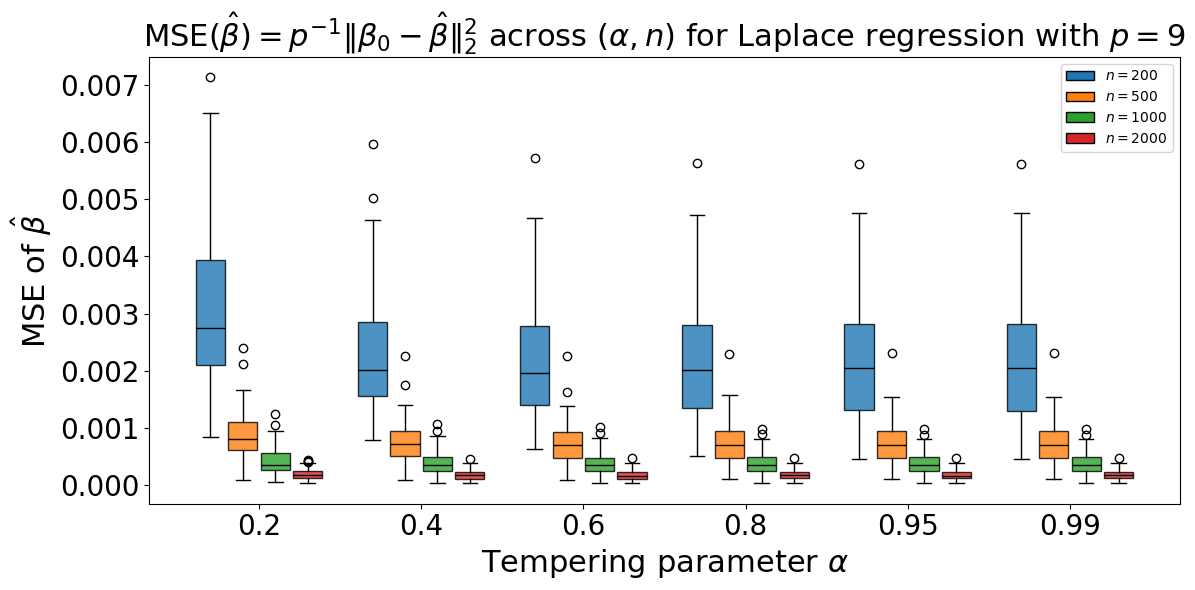

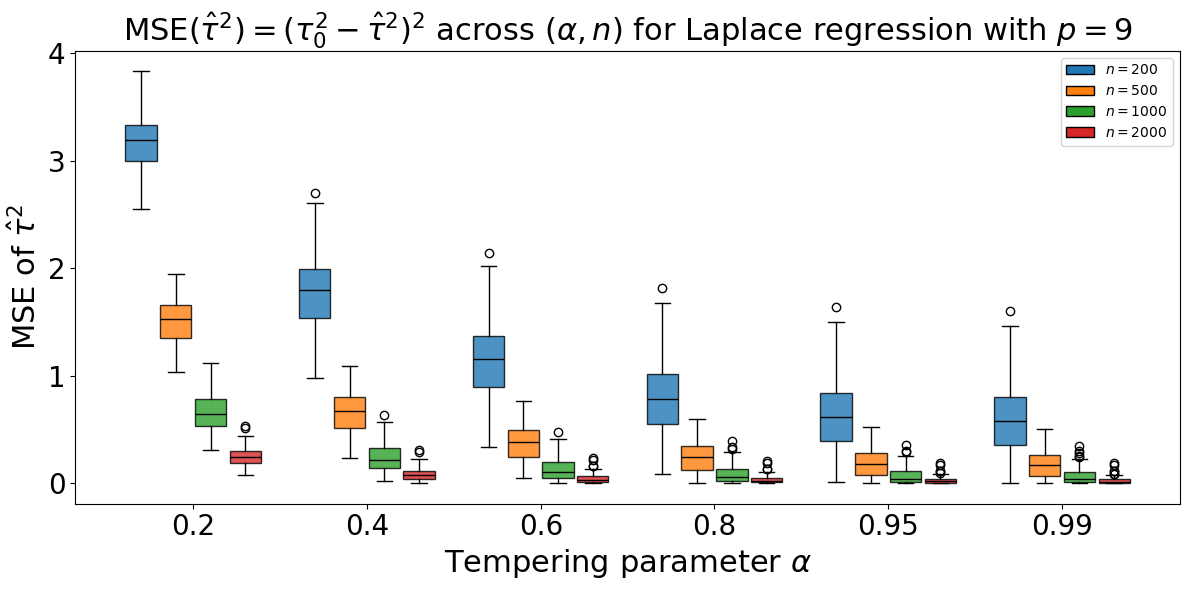

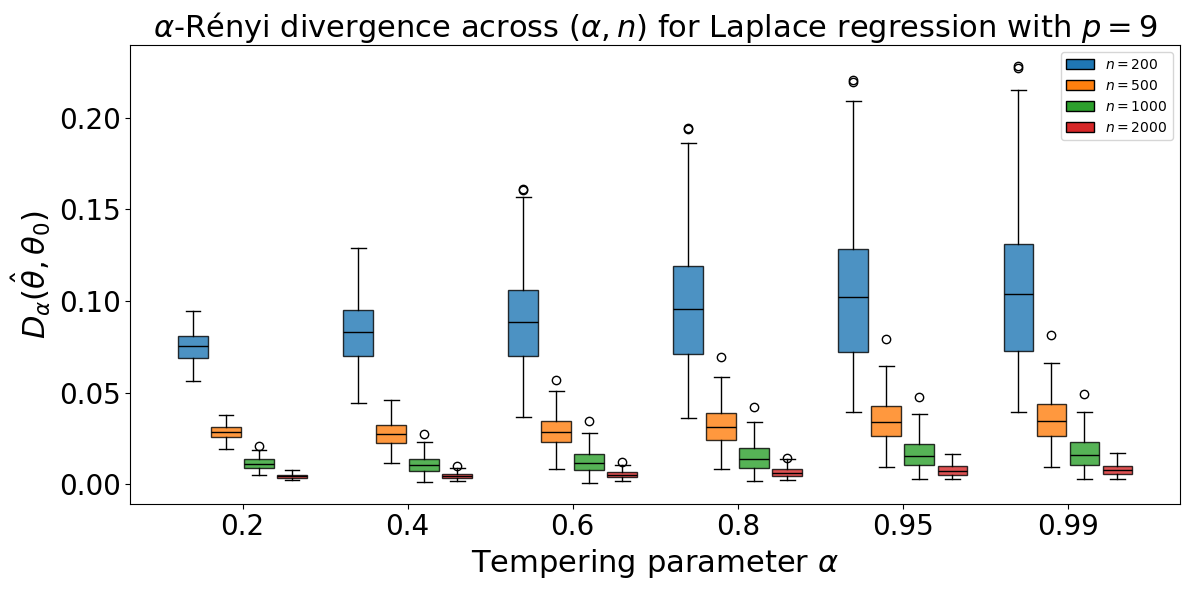

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# SETTINGS AND SAVED RESULTS
# ============================================================
output_dir = "results_sensitivity_calibration_alpha"

n_values = [200, 500, 1000, 2000]
alphas = [0.2, 0.4, 0.6, 0.8, 0.95, 0.99]

# Load the saved simulation results
all_results = {}

for n in n_values:
    result_path = os.path.join(
        output_dir,
        f"Laplace_metrics_alpha_n{n}.pkl"
    )

    with open(result_path, "rb") as f:
        all_results[n] = pickle.load(f)


# ============================================================
# GENERAL GROUPED BOXPLOT
# For each alpha, boxplots for all n appear side by side
# ============================================================
def make_grouped_boxplot_figure(
    results_dict,
    metric_key,
    y_label,
    title,
    save_path
):
    fig, ax = plt.subplots(figsize=(12, 6))

    num_alpha = len(alphas)
    num_n = len(n_values)

    base_positions = np.arange(num_alpha) + 1

    # Total horizontal span occupied by one alpha group
    group_width = 0.8
    box_width = group_width / num_n

    # Center the boxes around each alpha position
    offsets = np.linspace(
        -group_width / 2 + box_width / 2,
         group_width / 2 - box_width / 2,
         num_n
    )

    colors = plt.cm.tab10(np.arange(num_n))
    legend_handles = []

    for j, n in enumerate(n_values):
        positions = base_positions + offsets[j]

        data_n = [
            results_dict[n][metric_key][i, :]
            for i in range(num_alpha)
        ]

        bp = ax.boxplot(
            data_n,
            positions=positions,
            widths=box_width * 0.9,
            patch_artist=True,
            manage_ticks=False
        )

        for box in bp["boxes"]:
            box.set_facecolor(colors[j])
            box.set_alpha(0.8)

        for element in ["whiskers", "caps", "medians"]:
            for item in bp[element]:
                item.set_color("black")

        legend_handles.append(
            Patch(
                facecolor=colors[j],
                edgecolor="black",
                label=rf"$n={n}$"
            )
        )

    ax.set_xticks(base_positions)
    ax.set_xticklabels([str(alpha) for alpha in alphas])

    ax.set_xlabel(
        r"Tempering parameter $\alpha$",
        fontsize=22
    )
    ax.set_ylabel(y_label, fontsize=22)
    ax.set_title(title, fontsize=22)

    ax.legend(
        handles=legend_handles,
        loc="best"
    )

    ax.tick_params(axis="both", which="major", labelsize=20)
    
    fig.tight_layout()
    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# SUPPLEMENTARY FIGURES 13 AND 14
# ============================================================

# MSE of beta
make_grouped_boxplot_figure(
    results_dict=all_results,
    metric_key="mse_beta_TAVIE",
    y_label=r"MSE of $\hat{\beta}$",
    title=(
        r"$\mathrm{MSE}(\hat{\beta})"
        r"=p^{-1}\|\beta_0-\hat{\beta}\|_{2}^{2}$ "
        r"across $(\alpha,n)$ for Laplace regression with $p=9$"
    ),
    save_path=os.path.join(
        output_dir,
        "boxplot_mse_beta_alpha_laplace.pdf"
    )
)


# MSE of tau squared
make_grouped_boxplot_figure(
    results_dict=all_results,
    metric_key="mse_tau2_TAVIE",
    y_label=r"MSE of $\hat{\tau}^2$",
    title=(
        r"$\mathrm{MSE}(\hat{\tau}^{2})"
        r"=(\tau^2_0-\hat{\tau}^2)^2$ "
        r"across $(\alpha,n)$ for Laplace regression with $p=9$"
    ),
    save_path=os.path.join(
        output_dir,
        "boxplot_mse_tau2_alpha_laplace.pdf"
    )
)


# Alpha-Rényi divergence
make_grouped_boxplot_figure(
    results_dict=all_results,
    metric_key="renyi_TAVIE",
    y_label=r"$D_\alpha(\hat{\theta},\theta_0)$",
    title=(
        r"$\alpha$-Rényi divergence across $(\alpha,n)$ "
        r"for Laplace regression with $p=9$"
    ),
    save_path=os.path.join(
        output_dir,
        "boxplot_renyi_alpha_laplace.pdf"
    )
)

### Contour plots of the variational posterior for different $\alpha$ and $n$

The results are stored in `results_sensitivity_calibration_alpha/fit_results.pkl`

In [ ]:
from TAVIE import *
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln
from tqdm.auto import trange

# ============================================================
# SETTINGS
# ============================================================
total_p = 6 # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 5
tau2_true = 3.0
num_reps = 1                 # one fit per (n, alpha) is enough for contour plots
n_values = [1000, 2000, 4000]
alphas = [0.2, 0.4, 0.6, 0.95, 1.00]

# Choose any two coordinates of beta to visualize
# If fit_intercept=True, beta[0] is intercept
beta_idx1 = 1
beta_idx2 = 2

# Fix true beta once across all experiments
np.random.seed(123)
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p + 1)

output_dir = "results_sensitivity_calibration_alpha"
os.makedirs(output_dir, exist_ok=True)


# ============================================================
# MULTIVARIATE t DENSITY IN 2D
# If X ~ t_nu(mu, S), then density is:
#
#   Gamma((nu+d)/2)
#   ----------------------------- * (1 + q/nu)^(-(nu+d)/2)
#   Gamma(nu/2) (nu pi)^(d/2) |S|^(1/2)
#
# where q = (x-mu)^T S^{-1} (x-mu)
# ============================================================
def multivariate_t_pdf_2d(X, Y, mu, S, nu):
    """
    Evaluate bivariate Student-t density on a meshgrid.

    Parameters
    ----------
    X, Y : 2D np.ndarray
        Meshgrid arrays.
    mu : np.ndarray of shape (2,)
        Mean/location vector.
    S : np.ndarray of shape (2,2)
        Scale matrix.
    nu : float
        Degrees of freedom.

    Returns
    -------
    Z : 2D np.ndarray
        Density values on the grid.
    """
    d = 2
    pos = np.dstack((X, Y))   # shape (..., 2)

    S_inv = np.linalg.inv(S)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        raise ValueError("Scale matrix must be positive definite.")

    diff = pos - mu
    qf = np.einsum("...i,ij,...j->...", diff, S_inv, diff)

    log_const = (
        gammaln((nu + d) / 2.0)
        - gammaln(nu / 2.0)
        - (d / 2.0) * np.log(nu * np.pi)
        - 0.5 * logdet
    )
    log_kernel = -((nu + d) / 2.0) * np.log1p(qf / nu)

    return np.exp(log_const + log_kernel)


# ============================================================
# GENERATE DATA UNDER LAPLACE REGRESSION
# ============================================================
def generate_laplace_regression_data(n, p, beta_true, tau2_true, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X = np.random.normal(size=(n, p))
    error = np.random.laplace(loc=0.0, scale=1.0 / np.sqrt(tau2_true), size=n)
    y = beta_true[0] + X @ beta_true[1:] + error
    return X, y


# ============================================================
# FIT TAVIE AND EXTRACT VARIATIONAL PARAMETERS
# ============================================================
def fit_tavie_and_extract(X, y, alpha):
    p = X.shape[1]
    prior_params = [np.zeros(p + 1), 10*np.eye(p + 1), 0.005, 0.005]
    model = TAVIE_loc_scale(family="laplace", fit_intercept=True)
    model.fit(X, y, alpha=alpha, prior_params=prior_params, verbose=False)

    ve = model.get_variational_estimates()
    m_xi = np.asarray(ve["m_xi"])
    V_xi = np.asarray(ve["V_xi"])
    a_xi = float(ve["a_xi"])
    b_xi = float(ve["b_xi"])

    return {
        "model": model,
        "m_xi": m_xi,
        "V_xi": V_xi,
        "a_xi": a_xi,
        "b_xi": b_xi,
    }


# ============================================================
# FIT FOR ALL (n, alpha)
# ============================================================
fit_results = {}

for n in n_values:
    fit_results[n] = {}

    for alpha in alphas:
        # same seed across alpha for fair comparison within each n
        X, y = generate_laplace_regression_data(
            n=n,
            p=p,
            beta_true=beta_true,
            tau2_true=tau2_true,
            seed=1
        )

        res = fit_tavie_and_extract(X, y, alpha)

        fit_results[n][alpha] = {
            "X": X,
            "y": y,
            "m_xi": res["m_xi"],
            "V_xi": res["V_xi"],
            "a_xi": res["a_xi"],
            "b_xi": res["b_xi"],
        }

# Save raw fitted contour info
with open(os.path.join(output_dir, "fit_results.pkl"), "wb") as f:
    pickle.dump(fit_results, f, protocol=pickle.HIGHEST_PROTOCOL)

### Figure 12 of the Supplementary Materials

See: `results_sensitivity_calibration_alpha/contours_beta1_beta2.pdf`

/var/folders/ls/s91_zt990n9b6gdbr57m19900000gn/T/ipykernel_61327/804245713.py:18: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


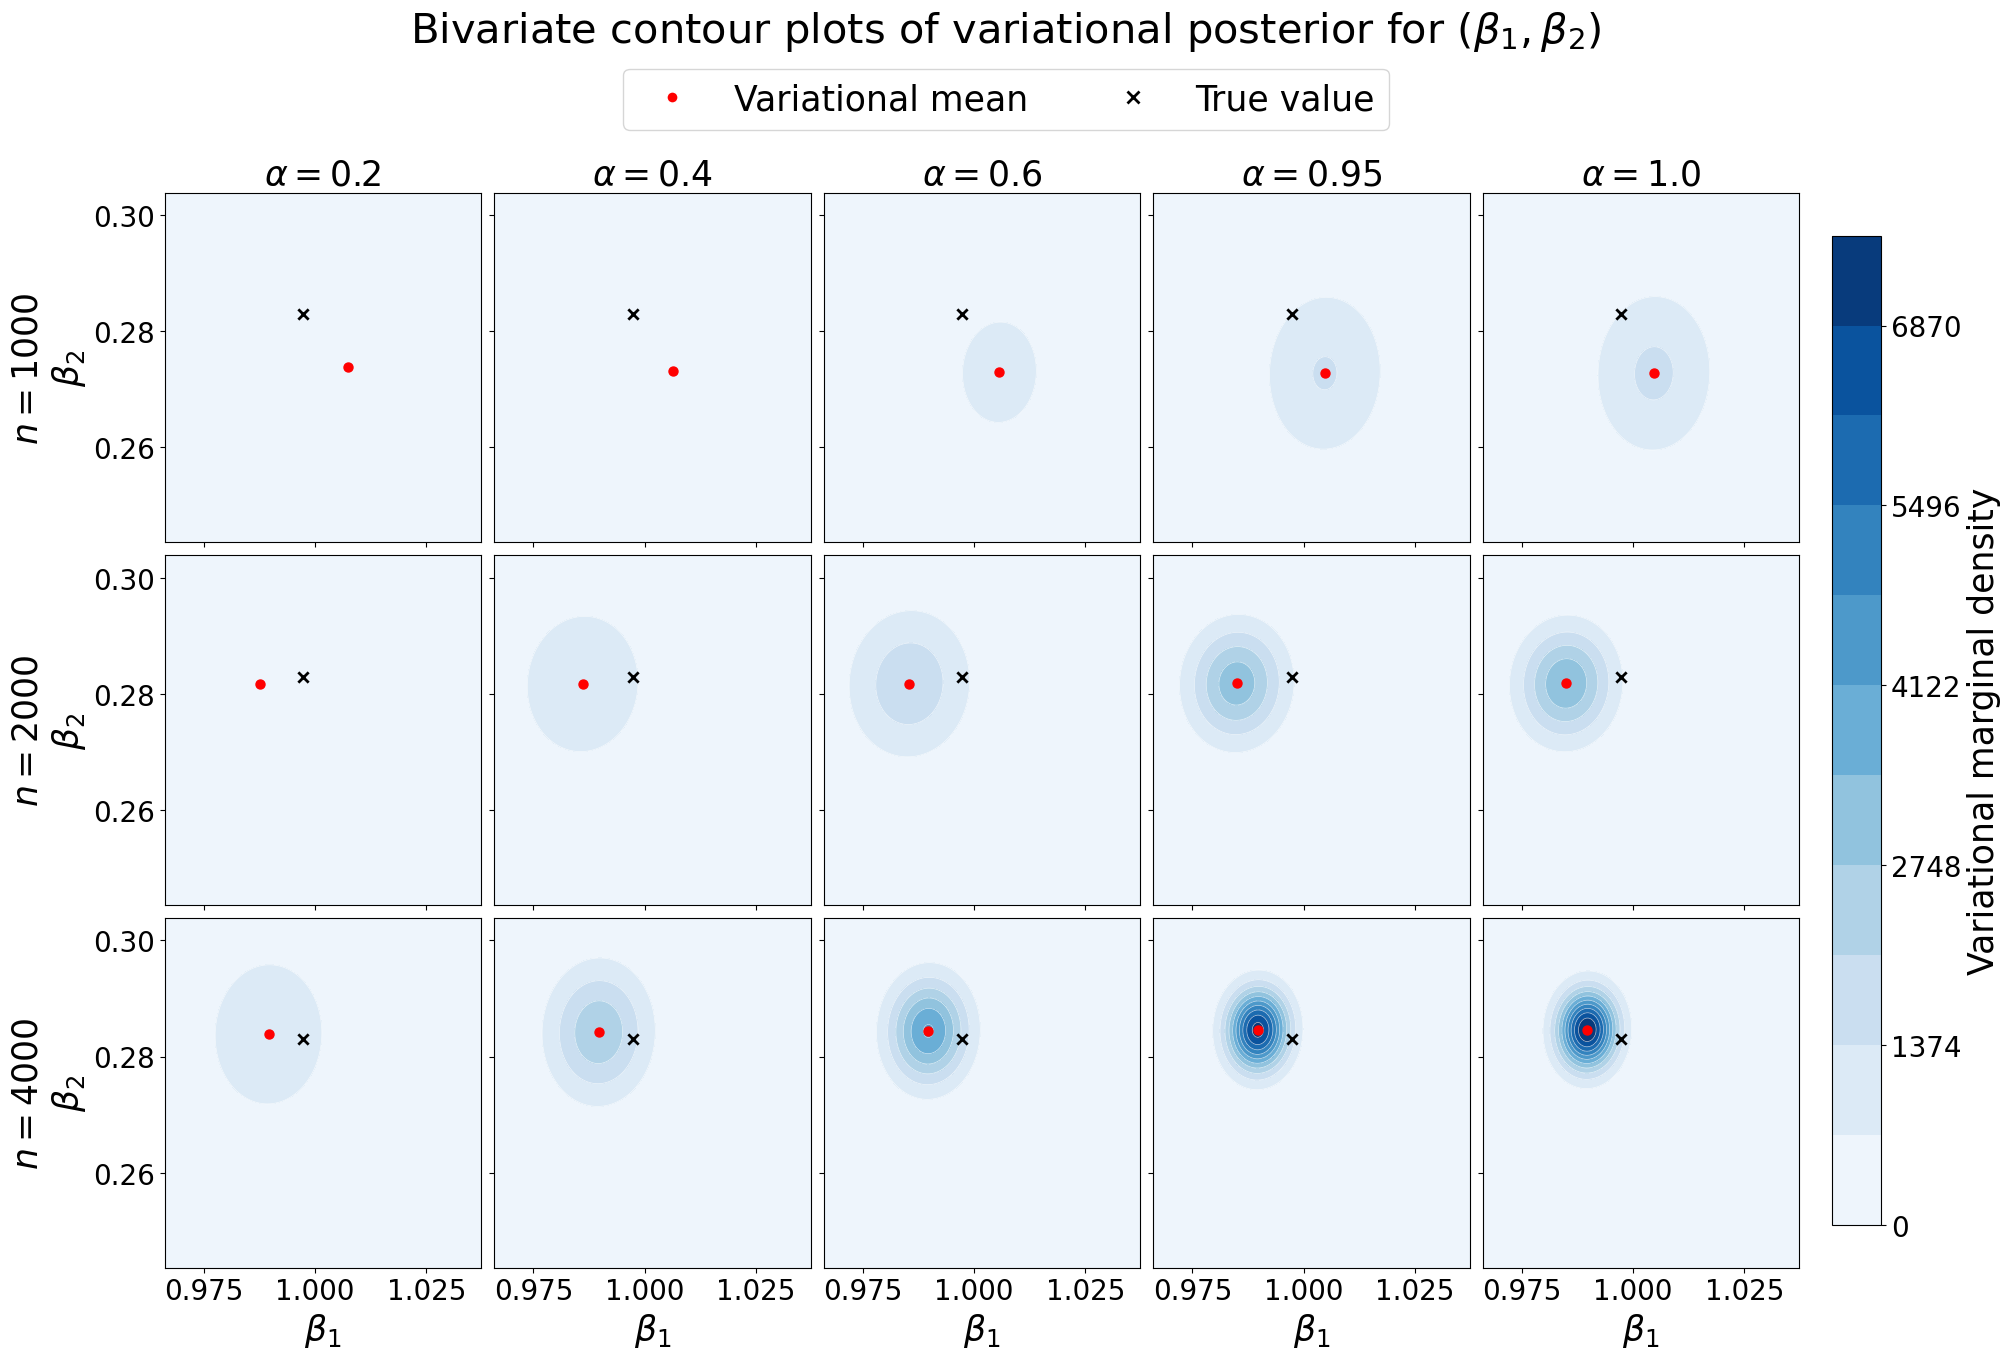

Figure saved to: results_sensitivity_calibration_alpha/contours_beta1_beta2.pdf


In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln


# ============================================================
# NUMPY 1.x / 2.x PICKLE COMPATIBILITY
# ============================================================
class NumPyCompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "numpy._core":
            module = "numpy.core"
        elif module.startswith("numpy._core."):
            module = "numpy.core." + module[len("numpy._core."):]

        return super().find_class(module, name)


# ============================================================
# SETTINGS
# ============================================================
total_p = 6 # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 5

n_values = [1000, 2000, 4000]
alphas = [0.2, 0.4, 0.6, 0.95, 1.0]

# Coordinates of beta displayed in the contour plots
beta_idx1 = 1
beta_idx2 = 2

# Reconstruct the true beta used in the simulation
np.random.seed(123)
beta_true = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=p + 1
)

output_dir = "results_sensitivity_calibration_alpha"


# ============================================================
# LOAD SAVED FIT RESULTS
# ============================================================
fit_results_path = os.path.join(
    output_dir,
    "fit_results.pkl"
)

with open(fit_results_path, "rb") as f:
    fit_results = NumPyCompatUnpickler(f).load()


# ============================================================
# BIVARIATE STUDENT-t DENSITY
# ============================================================
def multivariate_t_pdf_2d(X, Y, mu, S, nu):
    """
    Evaluate a bivariate Student-t density on a mesh grid.
    """
    d = 2
    positions = np.dstack((X, Y))

    S_inv = np.linalg.inv(S)
    sign, logdet = np.linalg.slogdet(S)

    if sign <= 0:
        raise ValueError("Scale matrix must be positive definite.")

    difference = positions - mu

    quadratic_form = np.einsum(
        "...i,ij,...j->...",
        difference,
        S_inv,
        difference
    )

    log_constant = (
        gammaln((nu + d) / 2.0)
        - gammaln(nu / 2.0)
        - (d / 2.0) * np.log(nu * np.pi)
        - 0.5 * logdet
    )

    log_kernel = (
        -((nu + d) / 2.0)
        * np.log1p(quadratic_form / nu)
    )

    return np.exp(log_constant + log_kernel)


# ============================================================
# COMMON AXIS LIMITS ACROSS ALL PANELS
# ============================================================
means1 = []
means2 = []
sds1 = []
sds2 = []

for n in n_values:
    for alpha in alphas:
        result = fit_results[n][alpha]

        m_xi = result["m_xi"]
        V_xi = result["V_xi"]
        a_xi = result["a_xi"]
        b_xi = result["b_xi"]

        means1.append(m_xi[beta_idx1])
        means2.append(m_xi[beta_idx2])

        if a_xi > 2:
            cov_beta = (
                b_xi / (a_xi - 2.0)
            ) * V_xi
        else:
            cov_beta = (
                b_xi / a_xi
            ) * V_xi

        sds1.append(
            np.sqrt(cov_beta[beta_idx1, beta_idx1])
        )
        sds2.append(
            np.sqrt(cov_beta[beta_idx2, beta_idx2])
        )

means1 = np.asarray(means1)
means2 = np.asarray(means2)
sds1 = np.asarray(sds1)
sds2 = np.asarray(sds2)

true_x = beta_true[beta_idx1]
true_y = beta_true[beta_idx2]

sd_scale = 1.0

x_min = min(
    np.min(means1 - sd_scale * sds1),
    true_x
)
x_max = max(
    np.max(means1 + sd_scale * sds1),
    true_x
)

y_min = min(
    np.min(means2 - sd_scale * sds2),
    true_y
)
y_max = max(
    np.max(means2 + sd_scale * sds2),
    true_y
)

x_padding = 0.05 * (x_max - x_min)
y_padding = 0.05 * (y_max - y_min)

x_min -= x_padding
x_max += x_padding
y_min -= y_padding
y_max += y_padding


# ============================================================
# COMMON EVALUATION GRID
# ============================================================
grid_size = 220

x_grid = np.linspace(x_min, x_max, grid_size)
y_grid = np.linspace(y_min, y_max, grid_size)

XX, YY = np.meshgrid(x_grid, y_grid)


# ============================================================
# FIND COMMON CONTOUR LEVELS
# ============================================================
all_densities = []

for n in n_values:
    for alpha in alphas:
        result = fit_results[n][alpha]

        m_xi = result["m_xi"]
        V_xi = result["V_xi"]
        a_xi = result["a_xi"]
        b_xi = result["b_xi"]

        beta_indices = [beta_idx1, beta_idx2]

        mu_2d = m_xi[beta_indices]

        V_2d = V_xi[
            np.ix_(beta_indices, beta_indices)
        ]

        S_2d = (b_xi / a_xi) * V_2d

        density = multivariate_t_pdf_2d(
            XX,
            YY,
            mu_2d,
            S_2d,
            a_xi
        )

        all_densities.append(density)

global_min = min(
    density.min()
    for density in all_densities
)

global_max = max(
    density.max()
    for density in all_densities
)

levels = np.linspace(
    global_min,
    global_max,
    12
)


# ============================================================
# FIGURE 12: CONTOUR GRID
# Rows correspond to n; columns correspond to alpha
# ============================================================
fig, axes = plt.subplots(
    nrows=len(n_values),
    ncols=len(alphas),
    figsize=(
        4.0 * len(alphas),
        4.0 * len(n_values)
    ),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# Handle one-row or one-column cases
if len(n_values) == 1 and len(alphas) == 1:
    axes = np.array([[axes]])
elif len(n_values) == 1:
    axes = axes[np.newaxis, :]
elif len(alphas) == 1:
    axes = axes[:, np.newaxis]

filled_contour = None
beta_indices = [beta_idx1, beta_idx2]

for i, n in enumerate(n_values):
    for j, alpha in enumerate(alphas):
        ax = axes[i, j]

        result = fit_results[n][alpha]

        m_xi = result["m_xi"]
        V_xi = result["V_xi"]
        a_xi = result["a_xi"]
        b_xi = result["b_xi"]

        mu_2d = m_xi[beta_indices]

        V_2d = V_xi[
            np.ix_(beta_indices, beta_indices)
        ]

        S_2d = (b_xi / a_xi) * V_2d

        density = multivariate_t_pdf_2d(
            XX,
            YY,
            mu_2d,
            S_2d,
            a_xi
        )

        # Filled density contours
        filled_contour = ax.contourf(
            XX,
            YY,
            density,
            levels=levels,
            cmap="Blues"
        )

        # White contour lines
        ax.contour(
            XX,
            YY,
            density,
            levels=levels,
            colors="white",
            linewidths=0.5,
            alpha=0.7
        )

        # Variational posterior mean
        ax.scatter(
            m_xi[beta_idx1],
            m_xi[beta_idx2],
            color="red",
            marker="o",
            s=42,
            zorder=3
        )

        # True parameter value
        ax.scatter(
            true_x,
            true_y,
            color="black",
            marker="x",
            s=55,
            linewidths=2,
            zorder=3
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        # Increase tick-label font size here if desired
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=20
        )

        if i == 0:
            ax.set_title(
                rf"$\alpha={alpha}$",
                fontsize=25
            )

        if j == 0:
            ax.set_ylabel(
                rf"$n={n}$"
                + "\n"
                + rf"$\beta_{{{beta_idx2}}}$",
                fontsize=25
            )

        if i == len(n_values) - 1:
            ax.set_xlabel(
                rf"$\beta_{{{beta_idx1}}}$",
                fontsize=25
            )


# ============================================================
# SHARED COLORBAR
# ============================================================
colorbar = fig.colorbar(
    filled_contour,
    ax=axes.ravel().tolist(),
    shrink=0.92,
    pad=0.02
)

colorbar.set_label(
    "Variational marginal density",
    fontsize=25
)

colorbar.ax.tick_params(labelsize=20)


# ============================================================
# SHARED LEGEND
# ============================================================
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor="red",
        markersize=8,
        label="Variational mean"
    ),
    plt.Line2D(
        [0],
        [0],
        marker="x",
        color="black",
        linewidth=0,
        markeredgewidth=2,
        markersize=8,
        label="True value"
    )
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 1.085),
    fontsize=25
)


# ============================================================
# TITLE AND OUTPUT
# ============================================================
fig.suptitle(
    rf"Bivariate contour plots of variational posterior for "
    rf"$(\beta_{{{beta_idx1}}},\beta_{{{beta_idx2}}})$",
    fontsize=30,
    y=1.12
)

figure_path = os.path.join(
    output_dir,
    f"contours_beta{beta_idx1}_beta{beta_idx2}.pdf"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {figure_path}")

### Frequentist coverage for different $\alpha$ for Laplace regression

The results are stored in `results_sensitivity_calibration_alpha/coverage_and_width_results.pkl`

In [ ]:
# required imports
from TAVIE import *
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import trange
from scipy.stats import t as student_t_dist
from scipy.stats import gamma as gamma_dist

# ============================================================
# SETTINGS
# ============================================================
total_p = 6 # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 5
n = 10_000
tau2_true = 3.0
num_reps = 100
alphas = np.round(np.linspace(0.05, 1.00, 20), 2)

# fixed true beta (includes intercept because fit_intercept=True)
np.random.seed(123)
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p + 1)

output_dir = "results_sensitivity_calibration_alpha"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# DATA GENERATION
# ============================================================
def generate_laplace_regression_data(n, p, beta_true, tau2_true, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X = np.random.normal(size=(n, p))
    error = np.random.laplace(loc=0.0, scale=1.0 / np.sqrt(tau2_true), size=n)
    y = beta_true[0] + X @ beta_true[1:] + error
    return X, y

# ============================================================
# 95% CREDIBLE INTERVALS FROM NG VARIATIONAL POSTERIOR
# ============================================================
def credible_intervals_from_ng(m_xi, V_xi, a_xi, b_xi, cred_level=0.95):
    alpha_tail = (1.0 - cred_level) / 2.0

    # beta marginals
    df_beta = a_xi
    beta_scales = np.sqrt((b_xi / a_xi) * np.diag(V_xi))
    beta_lower = student_t_dist.ppf(alpha_tail, df=df_beta, loc=m_xi, scale=beta_scales)
    beta_upper = student_t_dist.ppf(1.0 - alpha_tail, df=df_beta, loc=m_xi, scale=beta_scales)

    # tau^2 marginal
    gamma_shape = a_xi / 2.0
    gamma_scale = 2.0 / b_xi  # scipy uses shape-scale; model uses shape-rate
    tau2_lower = gamma_dist.ppf(alpha_tail, a=gamma_shape, scale=gamma_scale)
    tau2_upper = gamma_dist.ppf(1.0 - alpha_tail, a=gamma_shape, scale=gamma_scale)

    return beta_lower, beta_upper, tau2_lower, tau2_upper

# ============================================================
# STORAGE
# ============================================================
beta_coverage_by_alpha = np.zeros(len(alphas))
tau2_coverage_by_alpha = np.zeros(len(alphas))
overall_coverage_by_alpha = np.zeros(len(alphas))

beta_avg_width_by_alpha = np.zeros(len(alphas))
tau2_avg_width_by_alpha = np.zeros(len(alphas))
overall_avg_width_by_alpha = np.zeros(len(alphas))

results = {
    "p": p,
    "n": n,
    "tau2_true": tau2_true,
    "beta_true": beta_true,
    "alphas": alphas,
    "num_reps": num_reps,
    "beta_coord_coverage_matrix": np.zeros((len(alphas), num_reps, p + 1)),
    "tau2_coverage_matrix": np.zeros((len(alphas), num_reps)),
    "overall_param_coverage_matrix": np.zeros((len(alphas), num_reps, p + 2)),
    "beta_interval_width_matrix": np.zeros((len(alphas), num_reps, p + 1)),
    "tau2_interval_width_matrix": np.zeros((len(alphas), num_reps)),
    "overall_param_width_matrix": np.zeros((len(alphas), num_reps, p + 2)),
}

# ============================================================
# MAIN LOOP
# ============================================================
for i, alpha in enumerate(alphas):
    beta_cover_indicators = np.zeros((num_reps, p + 1))
    tau2_cover_indicators = np.zeros(num_reps)
    overall_cover_indicators = np.zeros((num_reps, p + 2))

    beta_interval_widths = np.zeros((num_reps, p + 1))
    tau2_interval_widths = np.zeros(num_reps)
    overall_interval_widths = np.zeros((num_reps, p + 2))

    for rep in trange(num_reps, desc=f"alpha={alpha:.2f}"):
        X, y = generate_laplace_regression_data(
            n=n,
            p=p,
            beta_true=beta_true,
            tau2_true=tau2_true,
            seed=rep + 1000
        )

        model = TAVIE_loc_scale(family="laplace", fit_intercept=True)
        model.fit(X, y, alpha=float(alpha), verbose=False)

        ve = model.get_variational_estimates()
        m_xi = np.asarray(ve["m_xi"])
        V_xi = np.asarray(ve["V_xi"])
        a_xi = float(ve["a_xi"])
        b_xi = float(ve["b_xi"])

        beta_lower, beta_upper, tau2_lower, tau2_upper = credible_intervals_from_ng(
            m_xi=m_xi,
            V_xi=V_xi,
            a_xi=a_xi,
            b_xi=b_xi,
            cred_level=0.95
        )

        # ----------------------------------------------------
        # COVERAGE
        # ----------------------------------------------------
        beta_cover = ((beta_true >= beta_lower) & (beta_true <= beta_upper)).astype(float)
        tau2_cover = float((tau2_true >= tau2_lower) and (tau2_true <= tau2_upper))

        beta_cover_indicators[rep, :] = beta_cover
        tau2_cover_indicators[rep] = tau2_cover

        overall_cover_indicators[rep, :-1] = beta_cover
        overall_cover_indicators[rep, -1] = tau2_cover

        # ----------------------------------------------------
        # INTERVAL WIDTHS
        # ----------------------------------------------------
        beta_width = beta_upper - beta_lower
        tau2_width = tau2_upper - tau2_lower

        beta_interval_widths[rep, :] = beta_width
        tau2_interval_widths[rep] = tau2_width

        overall_interval_widths[rep, :-1] = beta_width
        overall_interval_widths[rep, -1] = tau2_width

    # --------------------------------------------------------
    # AVERAGES BY ALPHA
    # --------------------------------------------------------
    beta_coverage_by_alpha[i] = beta_cover_indicators.mean()
    tau2_coverage_by_alpha[i] = tau2_cover_indicators.mean()
    overall_coverage_by_alpha[i] = overall_cover_indicators.mean()

    beta_avg_width_by_alpha[i] = beta_interval_widths.mean()
    tau2_avg_width_by_alpha[i] = tau2_interval_widths.mean()
    overall_avg_width_by_alpha[i] = overall_interval_widths.mean()

    # --------------------------------------------------------
    # SAVE MATRICES
    # --------------------------------------------------------
    results["beta_coord_coverage_matrix"][i, :, :] = beta_cover_indicators
    results["tau2_coverage_matrix"][i, :] = tau2_cover_indicators
    results["overall_param_coverage_matrix"][i, :, :] = overall_cover_indicators

    results["beta_interval_width_matrix"][i, :, :] = beta_interval_widths
    results["tau2_interval_width_matrix"][i, :] = tau2_interval_widths
    results["overall_param_width_matrix"][i, :, :] = overall_interval_widths

# ============================================================
# SAVE SUMMARIES
# ============================================================
results["beta_coverage_by_alpha"] = beta_coverage_by_alpha
results["tau2_coverage_by_alpha"] = tau2_coverage_by_alpha
results["overall_coverage_by_alpha"] = overall_coverage_by_alpha

results["beta_avg_width_by_alpha"] = beta_avg_width_by_alpha
results["tau2_avg_width_by_alpha"] = tau2_avg_width_by_alpha
results["overall_avg_width_by_alpha"] = overall_avg_width_by_alpha

with open(os.path.join(output_dir, "coverage_and_width_results.pkl"), "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

### Figure 15 of the Supplementary Materials

See: `results_sensitivity_calibration_alpha/coverage_overall_vs_alpha.pdf` and `results_sensitivity_calibration_alpha/width_overall_vs_alpha.pdf`

/var/folders/ls/s91_zt990n9b6gdbr57m19900000gn/T/ipykernel_61327/3840879907.py:16: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


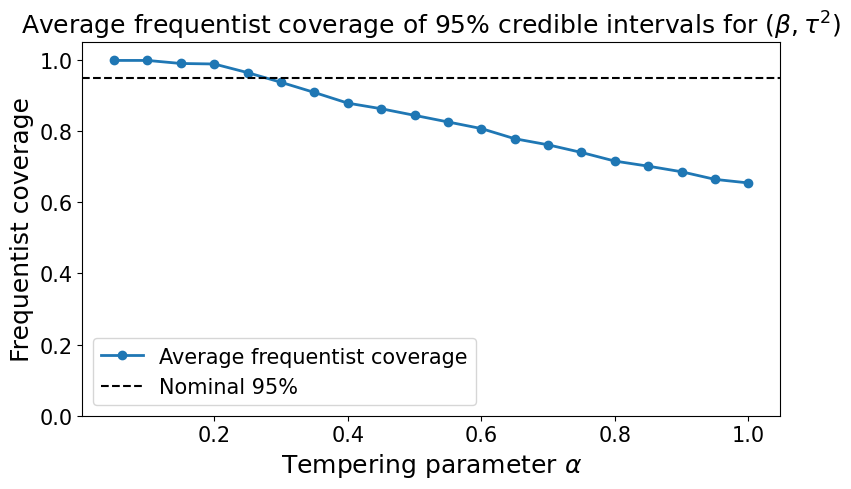

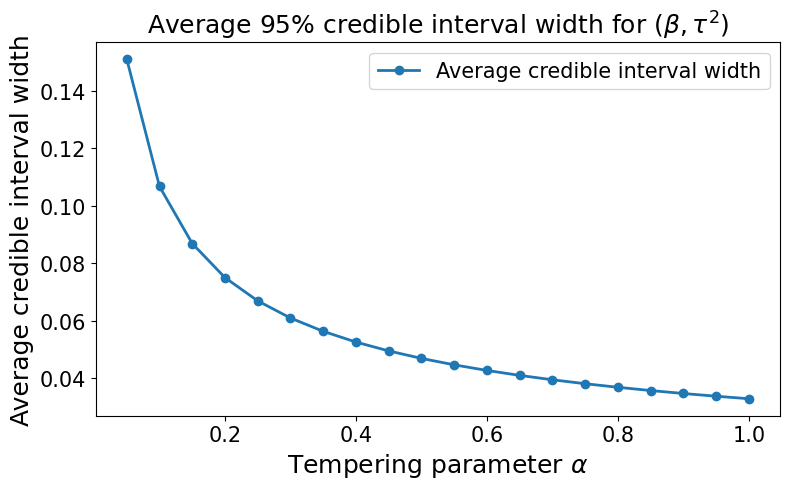

Coverage figure saved to: results_sensitivity_calibration_alpha/coverage_overall_vs_alpha.pdf
Width figure saved to: results_sensitivity_calibration_alpha/width_overall_vs_alpha.pdf


In [19]:
import os
import pickle
import matplotlib.pyplot as plt


# ============================================================
# NUMPY 1.x / 2.x PICKLE COMPATIBILITY
# ============================================================
class NumPyCompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "numpy._core":
            module = "numpy.core"
        elif module.startswith("numpy._core."):
            module = "numpy.core." + module[len("numpy._core."):]

        return super().find_class(module, name)


# ============================================================
# LOAD SAVED RESULTS
# ============================================================
output_dir = "results_sensitivity_calibration_alpha"

results_path = os.path.join(
    output_dir,
    "coverage_and_width_results.pkl"
)

with open(results_path, "rb") as f:
    results = NumPyCompatUnpickler(f).load()

alphas = results["alphas"]
overall_coverage_by_alpha = results["overall_coverage_by_alpha"]
overall_avg_width_by_alpha = results["overall_avg_width_by_alpha"]


# ============================================================
# FIGURE 15(a): FREQUENTIST COVERAGE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    alphas,
    overall_coverage_by_alpha,
    marker="o",
    linewidth=2,
    label="Average frequentist coverage"
)

ax.axhline(
    0.95,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Nominal 95%"
)

ax.set_xlabel(
    r"Tempering parameter $\alpha$",
    fontsize=18
)

ax.set_ylabel(
    "Frequentist coverage",
    fontsize=18
)

ax.set_title(
    r"Average frequentist coverage of 95% credible intervals "
    r"for $(\beta,\tau^2)$",
    fontsize=18
)

ax.set_ylim(0, 1.05)
ax.tick_params(axis="both", labelsize=15)
ax.legend(fontsize=15)

fig.tight_layout()

coverage_path = os.path.join(
    output_dir,
    "coverage_overall_vs_alpha.pdf"
)

fig.savefig(
    coverage_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# FIGURE 15(b): CREDIBLE-INTERVAL WIDTH
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    alphas,
    overall_avg_width_by_alpha,
    marker="o",
    linewidth=2,
    label="Average credible interval width"
)

ax.set_xlabel(
    r"Tempering parameter $\alpha$",
    fontsize=18
)

ax.set_ylabel(
    "Average credible interval width",
    fontsize=18
)

ax.set_title(
    r"Average 95% credible interval width for $(\beta,\tau^2)$",
    fontsize=18
)

ax.tick_params(axis="both", labelsize=15)
ax.legend(fontsize=15)

fig.tight_layout()

width_path = os.path.join(
    output_dir,
    "width_overall_vs_alpha.pdf"
)

fig.savefig(
    width_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"Coverage figure saved to: {coverage_path}")
print(f"Width figure saved to: {width_path}")

### 95% credible interval coverage boxplots for different $\alpha$ and increasing $n$

The results are stored in `results_sensitivity_calibration_alpha/coverage_boxplot_results.pkl`

In [ ]:
# required imports
from TAVIE import *
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import trange
from scipy.stats import t as student_t_dist
from scipy.stats import gamma as gamma_dist
from matplotlib.patches import Patch

# ============================================================
# SETTINGS
# ============================================================
total_p = 31 # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 30
tau2_true = 3.0
num_reps = 100
n_values = [200, 800, 2000, 10_000]
alphas = [0.3, 0.6, 0.95, 1.00]              

# fixed true beta (includes intercept because fit_intercept=True)
np.random.seed(123)
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p + 1)

output_dir = "results_sensitivity_calibration_alpha"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# DATA GENERATION
# ============================================================
def generate_laplace_regression_data(n, p, beta_true, tau2_true, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X = np.random.normal(size=(n, p))
    error = np.random.laplace(loc=0.0, scale=1.0 / np.sqrt(tau2_true), size=n)
    y = beta_true[0] + X @ beta_true[1:] + error
    return X, y

# ============================================================
# 95% CREDIBLE INTERVALS FROM NG VARIATIONAL POSTERIOR
# ============================================================
def credible_intervals_from_ng(m_xi, V_xi, a_xi, b_xi, cred_level=0.95):
    alpha_tail = (1.0 - cred_level) / 2.0

    # beta marginals
    df_beta = a_xi
    beta_scales = np.sqrt((b_xi / a_xi) * np.diag(V_xi))
    beta_lower = student_t_dist.ppf(alpha_tail, df=df_beta, loc=m_xi, scale=beta_scales)
    beta_upper = student_t_dist.ppf(1.0 - alpha_tail, df=df_beta, loc=m_xi, scale=beta_scales)

    # tau^2 marginal
    gamma_shape = a_xi / 2.0
    gamma_scale = 2.0 / b_xi
    tau2_lower = gamma_dist.ppf(alpha_tail, a=gamma_shape, scale=gamma_scale)
    tau2_upper = gamma_dist.ppf(1.0 - alpha_tail, a=gamma_shape, scale=gamma_scale)

    return beta_lower, beta_upper, tau2_lower, tau2_upper

# ============================================================
# STORAGE
# overall coverage per repetition:
# shape = (num_alphas, num_n_values, num_reps)
# each entry is the average coverage across all model params
# ============================================================
overall_coverage_rep = np.zeros((len(alphas), len(n_values), num_reps))

results = {
    "p": p,
    "tau2_true": tau2_true,
    "beta_true": beta_true,
    "alphas": alphas,
    "n_values": n_values,
    "num_reps": num_reps,
    "overall_coverage_rep": overall_coverage_rep,
}

# ============================================================
# MAIN LOOP
# For each alpha and n:
#   - run 100 datasets
#   - for each dataset compute coverage indicators for p+2 params
#   - average over params within that repetition
#   - store the repetition-level average coverage
# ============================================================
for i, alpha in enumerate(alphas):
    for j, n in enumerate(n_values):
        rep_coverages = np.zeros(num_reps)

        for rep in trange(num_reps, desc=f"alpha={alpha}, n={n}"):
            X, y = generate_laplace_regression_data(
                n=n,
                p=p,
                beta_true=beta_true,
                tau2_true=tau2_true,
                seed=10000 * i + 100 * j + rep
            )

            model = TAVIE_loc_scale(family="laplace", fit_intercept=True)
            model.fit(X, y, alpha=float(alpha), verbose=False)

            ve = model.get_variational_estimates()
            m_xi = np.asarray(ve["m_xi"])
            V_xi = np.asarray(ve["V_xi"])
            a_xi = float(ve["a_xi"])
            b_xi = float(ve["b_xi"])

            beta_lower, beta_upper, tau2_lower, tau2_upper = credible_intervals_from_ng(
                m_xi=m_xi,
                V_xi=V_xi,
                a_xi=a_xi,
                b_xi=b_xi,
                cred_level=0.95
            )

            # coverage indicators for beta coordinates
            beta_cover = ((beta_true >= beta_lower) & (beta_true <= beta_upper)).astype(float)

            # coverage indicator for tau^2
            tau2_cover = float((tau2_true >= tau2_lower) and (tau2_true <= tau2_upper))

            # average over all model parameters: p+1 betas + 1 tau2
            all_cover = np.concatenate([beta_cover, np.array([tau2_cover])])
            rep_coverages[rep] = all_cover.mean()

        overall_coverage_rep[i, j, :] = rep_coverages

# save results
results["overall_coverage_rep"] = overall_coverage_rep
results["overall_coverage_mean_by_n"] = overall_coverage_rep.mean(axis=2)

with open(os.path.join(output_dir, "coverage_boxplot_results.pkl"), "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

### Figure 16 in Supplementary Materials

See: `results_sensitivity_calibration_alpha/coverage_boxplots_by_n_alpha.pdf`

/var/folders/ls/s91_zt990n9b6gdbr57m19900000gn/T/ipykernel_61327/3774799015.py:18: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


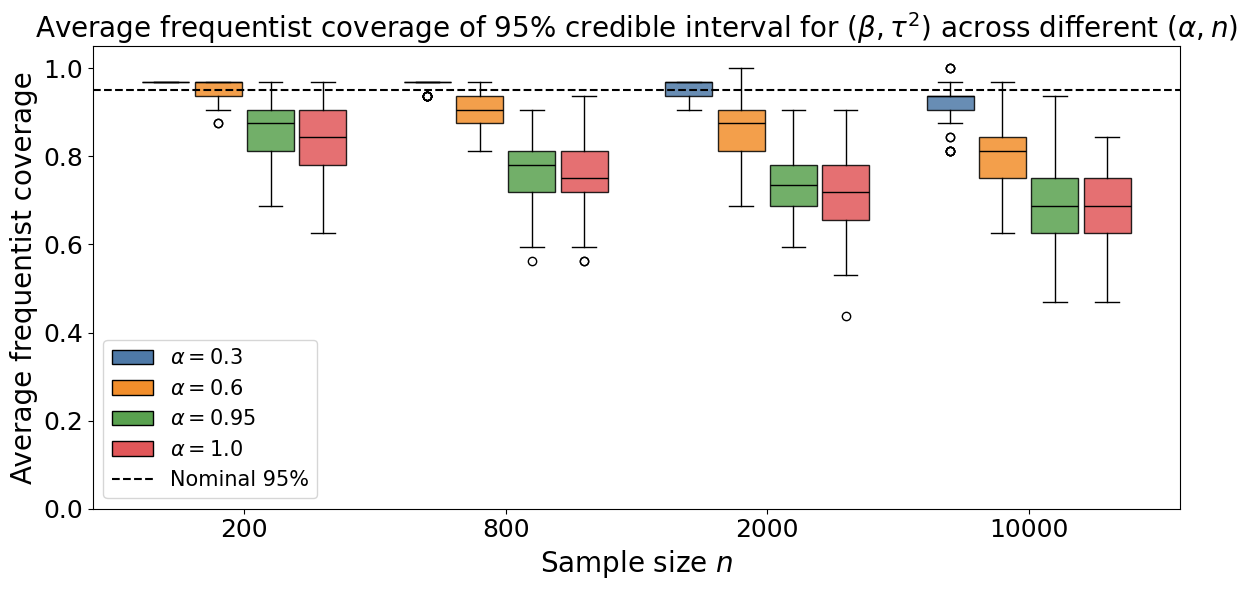

Figure saved to: results_sensitivity_calibration_alpha/coverage_boxplots_by_n_alpha.pdf


In [22]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# NUMPY 1.x / 2.x PICKLE COMPATIBILITY
# ============================================================
class NumPyCompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "numpy._core":
            module = "numpy.core"
        elif module.startswith("numpy._core."):
            module = "numpy.core." + module[len("numpy._core."):]

        return super().find_class(module, name)


# ============================================================
# LOAD SAVED RESULTS
# ============================================================
output_dir = "results_sensitivity_calibration_alpha"

results_path = os.path.join(
    output_dir,
    "coverage_boxplot_results.pkl"
)

with open(results_path, "rb") as f:
    results = NumPyCompatUnpickler(f).load()

overall_coverage_rep = results["overall_coverage_rep"]
n_values = results["n_values"]
alphas = results["alphas"]


# ============================================================
# FIGURE 16: GROUPED COVERAGE BOXPLOTS
# One group for each n and one color for each alpha
# ============================================================
def plot_grouped_coverage_boxplots(
    overall_coverage_rep,
    n_values,
    alphas,
    output_dir
):
    fig, ax = plt.subplots(figsize=(12, 6))

    num_n = len(n_values)
    num_alpha = len(alphas)

    base_positions = np.arange(num_n) + 1

    group_width = 0.8
    box_width = group_width / num_alpha

    offsets = np.linspace(
        -group_width / 2 + box_width / 2,
         group_width / 2 - box_width / 2,
         num_alpha
    )

    colors = [
        "#4E79A7",
        "#F28E2B",
        "#59A14F",
        "#E15759",
        "#B07AA1"
    ][:num_alpha]

    legend_handles = []

    for i, alpha in enumerate(alphas):
        positions = base_positions + offsets[i]

        data_alpha = [
            overall_coverage_rep[i, j, :]
            for j in range(num_n)
        ]

        boxplot = ax.boxplot(
            data_alpha,
            positions=positions,
            widths=box_width * 0.9,
            patch_artist=True,
            manage_ticks=False
        )

        for box in boxplot["boxes"]:
            box.set_facecolor(colors[i])
            box.set_alpha(0.85)

        for element in ["whiskers", "caps", "medians"]:
            for item in boxplot[element]:
                item.set_color("black")

        legend_handles.append(
            Patch(
                facecolor=colors[i],
                edgecolor="black",
                label=rf"$\alpha={alpha}$"
            )
        )

    # Nominal coverage reference line
    ax.axhline(
        0.95,
        linestyle="--",
        linewidth=1.5,
        color="black"
    )

    nominal_handle = plt.Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="Nominal 95%"
    )

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [str(n) for n in n_values],
        rotation=0
    )

    ax.set_xlabel(
        r"Sample size $n$",
        fontsize=20
    )

    ax.set_ylabel(
        "Average frequentist coverage",
        fontsize=20
    )

    ax.set_title(
        r"Average frequentist coverage of 95% credible interval "
        r"for $(\beta,\tau^{2})$ across different $(\alpha,n)$",
        fontsize=20
    )

    ax.set_ylim(0, 1.05)

    # Tick-label font size
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=18
    )

    ax.legend(
        handles=legend_handles + [nominal_handle],
        loc="best",
        fontsize=15
    )

    fig.tight_layout()

    figure_path = os.path.join(
        output_dir,
        "coverage_boxplots_by_n_alpha.pdf"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Figure saved to: {figure_path}")


# ============================================================
# GENERATE FIGURE 16
# ============================================================
plot_grouped_coverage_boxplots(
    overall_coverage_rep=overall_coverage_rep,
    n_values=n_values,
    alphas=alphas,
    output_dir=output_dir
)

## Practical Recommendation for calibrating $\alpha$: Section 2.4 of Main Manuscript and Section F of Supplementary Materials

### Choice of the tempering parameter $\alpha$ based on "Calibrating general posterior credible regions" (Syring and Martin, Bka, 2019)

For a practical recommendation on choosing the likelihood tempering parameter $\alpha \in (0, 1]$, we follow Algorithm 1 of Syring and Martin (2019; Bka) [https://academic.oup.com/biomet/article/106/2/479/5237467]. We describe and illustrate the algorithm with respect to TAVIE-SSG Type I Student's-$t$ model (known degrees of freedom $\nu\in \mathbb N$), where the parameter set is $\theta = (\beta^{\top}, \tau^{2})^{\top} \in \mathbb{R}^{p+2}$. In general, the algorithm can be applied to other candidate models in TAVIE-SSG across Type I and Type II families.

Fix a target credibility level $1-\gamma \in (0, 1)$, a convergence tolerance $\mathcal{E} > 0$, and initial guess $\alpha^{(0)} \in (0, 1]$. Let $\mathcal{D}_n := \{(y_i, \mathbf x_i):1\leq i \leq n\}$ denote the observed data, and let:
$$
\widehat{\theta}(\mathbb{P}_n) = (\widehat{\beta}(\mathbb P_n)^{\top}, \widehat{\tau}^{2}(\mathbb P_n))^{\top} \in \mathbb{R}^{p+2},
$$
be a plug-in estimate obtained from the TAVIE-SSG Student's-$t$ model fit with fixed degrees of freedom $\nu$ on the observed data. For each value of $\alpha$, let:
$$
\mathcal{C}_{\alpha, \gamma}(\mathcal D_n) = \{\theta\equiv (\beta^{\top}, \tau^2)^{\top}: \pi_{\alpha}(\theta\mid \mathcal D_n, \xi) \geq c_{\gamma}(\alpha)\},
$$
denote the joint $100(1-\gamma)\%$ high-posterior density (HPD) credible region under the variational posterior $\pi_{\alpha}(\theta \mid \mathcal D_n, \xi)$, where $c_{\gamma}(\alpha)$ is chosen so that the variational posterior probability assigned to $\mathcal{C}_{\alpha, \gamma}(\mathcal D_n)$ is $1-\gamma$. Then define the empirical coverage probability function:
$$
\widehat{c}_{\gamma}(\alpha; \mathbb P_n) = \tfrac{1}{B}\sum_{b=1}^{B}\mathbf{1}\left\{\widehat{\theta}(\mathbb P_n) \in \mathcal{C}_{\alpha, \gamma}(\mathcal D_{n(b)}^{\star})\right\},
$$
where $\mathcal{D}_{n(b)}^{\star}:= \{(y_{ib}^{\star}, \mathbf{x}_{ib}^{\star}):1\leq i \leq n\}$ for $1\leq b \leq B$, are $B$ bootstrap (with replacement) resamples from the observed data. The proposal of Syring and Martin (2019; Bka) is to choose $\alpha$ so that: $\widehat{c}_{\gamma}(\alpha;\mathbb P_n) = 1-\gamma$. The algorithm is presented as follows.

**Algorithm: Calibrating $\alpha\in (0, 1]$ for TAVIE-SSG Type I Student's-$t$ model.**

Fix convergence tolerance $\mathcal E > 0$, an initial guess $\alpha^{(0)}$, and $B$ bootstrap samples $\mathcal{D}_n^{\star}:= \{(y_{ib}^{\star}, \mathbf{x}_{ib}^{\star}):1\leq i \leq n\}$ for $1\leq b \leq B$. Set $t \leftarrow 0$ and **do**:

*Step 1*: For each $1\leq b \leq B$, fit the TAVIE-SSG Type I Student's-$t$ model on $\mathcal{D}_{n(b)}^{\star}$ with tempering parameter $\alpha^{(t)}$, yielding the fitted Normal-Gamma variational posterior distribution $\pi_{\xi, b}(\theta)\equiv \pi_{\alpha^{(t)}}(\theta\mid \mathcal{D}^{\star}_{n(b)}, \xi)$. Next, generate $M$ Monte Carlo (MC) samples: $(\theta_b^{(1)}, \ldots, \theta_b^{(M)}) \sim \pi_{\alpha^{(t)}}(\theta\mid \mathcal{D}^{\star}_{n(b)}, \xi)$, and compute the corresponding joint variational log-densities: $\ell_b^{(m)} = \log \pi_{\xi, b}(\theta_b^{(m)})$ for $1\leq m \leq M$. Let $\widehat{c}_{\gamma, b}^{\mathrm{MC}}$ denote the empirical lower $\gamma$-quantile of $\{\ell_{b}^{(m)}\}_{m=1}^{M}$. Then define the joint $100(1-\gamma)\%$ HPD credible region by: $\mathcal C_{\alpha^{(t)}, \gamma}(\mathcal{D}_{n(b)}^{\star}) = \{\theta: \log \pi_{\xi, b}(\theta) \geq \widehat{c}_{\gamma, b}^{\mathrm{MC}}\}$.

*Step 2*: Evaluate the empirical coverage probability, i.e., $\widehat{c}_{\gamma}(\alpha^{(t)}; \mathbb{P}_n) = \tfrac{1}{B}\sum_{b=1}^{B}\mathbf{1}\left\{\widehat{\theta}(\mathbb P_n) \in \mathcal{C}_{\alpha^{(t)}, \gamma}(\mathcal{D}_{n(b)}^{\star})\right\}$.

*Step 3*: If $|\widehat{c}_{\gamma}(\alpha^{(t)}; \mathbb{P}_n) - \overline{1-\gamma}| < \mathcal{E}$, then stop and return $\alpha^{(t)}$ as the calibrated value of likelihood tempering parameter. Otherwise, update $\alpha^{(t)}$ using (Robbins and Monro; 1951):
$$
\alpha^{(t+1)} = \Pi_{[\alpha_{\mathrm{min}}, \alpha_{\mathrm{max}}]}\left[\alpha^{(t)} + s\kappa_t\left\{\widehat{c}_{\gamma}(\alpha^{(t)}; \mathbb{P}_n) - \overline{1-\gamma}\right\}\right],
$$
where $\kappa_t = (t+1)^{-0.51}$ (from Syring and Martin (2019; Bka)), $s=1$, and $\Pi_{[\alpha_{\mathrm{min}}, \alpha_{\mathrm{max}}]}$ denotes the projection onto the admissible interval $[\alpha_{\mathrm{min}}, \alpha_{\mathrm{max}}]$. Set $t\leftarrow t+1$ and go back to Step 1.

### Auxiliary Functions for $\alpha$ Calibration

In [56]:
# required imports
import os
import numpy as np
import matplotlib.pyplot as plt
from TAVIE import *
from scipy.special import gammaln

# ============================================================
# 0. DATA GENERATION FOR STUDENT'S-t REGRESSION
# ============================================================
def generate_student_regression_data(n, p, beta_true, tau2_true, nu, seed=None):
    if seed is not None:
        np.random.seed(seed)

    X = np.random.normal(size=(n, p))
    error = np.random.standard_t(df=nu, size=n) / np.sqrt(tau2_true)
    y = beta_true[0] + X @ beta_true[1:] + error
    return X, y


# ============================================================
# 1. BOOTSTRAP RESAMPLING OF (X, y)
# ============================================================
def bootstrap_xy(X, y, rng):
    n = X.shape[0]
    idx = rng.integers(low=0, high=n, size=n)
    return X[idx], y[idx]


# ============================================================
# 2. FIT TAVIE STUDENT MODEL AND EXTRACT NG PARAMETERS
# ============================================================
def fit_tavie_student_extract(
    X,
    y,
    nu,
    alpha_temp,
    prior_params=None,
    maxiter=1000,
    tol=1e-9,
    verbose=False
):
    model = TAVIE_loc_scale(
        family="student",
        fit_intercept=True,
        scale_X=False,
        scale_y=False
    )

    model.fit(
        X=X,
        y=y,
        prior_params=prior_params,
        alpha=float(alpha_temp),
        maxiter=maxiter,
        tol=tol,
        verbose=verbose,
        nu=nu
    )

    ve = model.get_variational_estimates()

    m_xi = np.asarray(ve["m_xi"])
    V_xi = np.asarray(ve["V_xi"])
    a_xi = float(ve["a_xi"])
    b_xi = float(ve["b_xi"])

    beta_mean, tau2_mean = model.get_TAVIE_means(verbose=False)

    return {
        "model": model,
        "m_xi": m_xi,
        "V_xi": V_xi,
        "a_xi": a_xi,
        "b_xi": b_xi,
        "beta_mean": np.asarray(beta_mean),
        "tau2_mean": float(tau2_mean),
    }


# ============================================================
# 3. JOINT LOG-DENSITY OF THE NORMAL-GAMMA POSTERIOR
# ============================================================
def logpdf_normal_gamma(beta, tau2, m, V, a, b):
    if tau2 <= 0:
        return -np.inf

    d = len(m)
    sign, logdetV = np.linalg.slogdet(V)
    if sign <= 0:
        raise ValueError("V must be positive definite.")

    Vinv = np.linalg.inv(V)
    diff = beta - m
    quad = diff @ Vinv @ diff

    log_norm = (
        -0.5 * d * np.log(2.0 * np.pi)
        -0.5 * logdetV
        + 0.5 * d * np.log(tau2)
        - 0.5 * tau2 * quad
    )

    shape = a / 2.0
    rate = b / 2.0
    log_gamma = (
        shape * np.log(rate)
        - gammaln(shape)
        + (shape - 1.0) * np.log(tau2)
        - rate * tau2
    )

    return log_norm + log_gamma


# ============================================================
# 4. SAMPLING FROM THE NORMAL-GAMMA POSTERIOR
# ============================================================
def sample_normal_gamma(m, V, a, b, M=5000, seed=None):
    rng = np.random.default_rng(seed)
    d = len(m)

    shape = a / 2.0
    scale = 2.0 / b
    tau2_samples = rng.gamma(shape=shape, scale=scale, size=M)

    L = np.linalg.cholesky(V)
    z = rng.normal(size=(M, d))
    beta_samples = np.empty((M, d))

    for i in range(M):
        beta_samples[i] = m + (L @ z[i]) / np.sqrt(tau2_samples[i])

    return beta_samples, tau2_samples


# ============================================================
# 5. JOINT HPD LOG-DENSITY CUTOFF
# ============================================================
def hpd_logdensity_cutoff_ng(m, V, a, b, cred_level=0.95, M=5000, seed=None):
    beta_samps, tau2_samps = sample_normal_gamma(m, V, a, b, M=M, seed=seed)

    logdens = np.array([
        logpdf_normal_gamma(beta_samps[i], tau2_samps[i], m, V, a, b)
        for i in range(M)
    ])

    cutoff = np.quantile(logdens, 1.0 - cred_level)
    return float(cutoff)


# ============================================================
# 6. JOINT HPD MEMBERSHIP TEST
# ============================================================
def is_in_joint_hpd_region(beta0, tau20, m, V, a, b, cutoff):
    logd0 = logpdf_normal_gamma(beta0, tau20, m, V, a, b)
    return float(logd0 >= cutoff)


# ============================================================
# 7. PLUG-IN TARGET theta_hat(P_n)
# ============================================================
def plugin_theta_hat(
    X,
    y,
    nu,
    prior_params=None,
    alpha_plugin=1.0,
    maxiter=1000,
    tol=1e-9,
    verbose=False
):
    fit = fit_tavie_student_extract(
        X=X,
        y=y,
        nu=nu,
        alpha_temp=alpha_plugin,
        prior_params=prior_params,
        maxiter=maxiter,
        tol=tol,
        verbose=verbose
    )

    return {
        "beta": fit["beta_mean"].copy(),
        "tau2": float(fit["tau2_mean"])
    }


# ============================================================
# 8. BOOTSTRAP EMPIRICAL COVERAGE FOR ONE alpha_temp
# ============================================================
def empirical_joint_coverage_for_alpha(
    X,
    y,
    nu,
    alpha_temp,
    theta_hat,
    B=100,
    cred_level=0.95,
    prior_params=None,
    maxiter_fit=1000,
    tol_fit=1e-9,
    M_hpd=4000,
    seed=123,
    verbose=False
):
    rng = np.random.default_rng(seed)
    cover_indicators = np.zeros(B)

    for b in range(B):
        Xb, yb = bootstrap_xy(X, y, rng)

        fit_b = fit_tavie_student_extract(
            X=Xb,
            y=yb,
            nu=nu,
            alpha_temp=alpha_temp,
            prior_params=prior_params,
            maxiter=maxiter_fit,
            tol=tol_fit,
            verbose=verbose
        )

        cutoff_b = hpd_logdensity_cutoff_ng(
            m=fit_b["m_xi"],
            V=fit_b["V_xi"],
            a=fit_b["a_xi"],
            b=fit_b["b_xi"],
            cred_level=cred_level,
            M=M_hpd,
            seed=seed + 17 * b + 999
        )

        cover_indicators[b] = is_in_joint_hpd_region(
            beta0=theta_hat["beta"],
            tau20=theta_hat["tau2"],
            m=fit_b["m_xi"],
            V=fit_b["V_xi"],
            a=fit_b["a_xi"],
            b=fit_b["b_xi"],
            cutoff=cutoff_b
        )

    return {
        "coverage_hat": float(np.mean(cover_indicators)),
        "cover_indicators": cover_indicators
    }


# ============================================================
# 9. PILOT GRID SEARCH
# ============================================================
def pilot_alpha_grid_joint_hpd(
    X,
    y,
    nu,
    theta_hat,
    alpha_grid,
    B=30,
    cred_level=0.95,
    prior_params=None,
    maxiter_fit=1000,
    tol_fit=1e-9,
    M_hpd=3000,
    seed=123,
    verbose=False
):
    coverage_grid = []

    for j, a in enumerate(alpha_grid):
        out = empirical_joint_coverage_for_alpha(
            X=X,
            y=y,
            nu=nu,
            alpha_temp=float(a),
            theta_hat=theta_hat,
            B=B,
            cred_level=cred_level,
            prior_params=prior_params,
            maxiter_fit=maxiter_fit,
            tol_fit=tol_fit,
            M_hpd=M_hpd,
            seed=seed + 1000 * j,
            verbose=verbose
        )
        coverage_grid.append(out["coverage_hat"])

    return np.asarray(coverage_grid)


# ============================================================
# 10. STOCHASTIC-APPROXIMATION CALIBRATION OF alpha_temp
# ============================================================
def calibrate_alpha_student_tavie_joint_hpd(
    X,
    y,
    nu,
    prior_params=None,
    cred_level=0.95,
    alpha_init=0.5,
    alpha_min=0.05,
    alpha_max=1.0,
    B=100,
    max_sa_iter=20,
    tol_cov=0.01,
    step_exponent=0.51,
    step_scale=0.5,
    direction=+1,
    alpha_plugin=1.0,
    maxiter_fit=1000,
    tol_fit=1e-9,
    M_hpd=4000,
    seed=123,
    verbose=True
):
    target_cov = cred_level

    theta_hat = plugin_theta_hat(
        X=X,
        y=y,
        nu=nu,
        prior_params=prior_params,
        alpha_plugin=alpha_plugin,
        maxiter=maxiter_fit,
        tol=tol_fit,
        verbose=False
    )

    alpha_t = float(alpha_init)
    history = []

    for t in range(max_sa_iter):
        kappa_t = step_scale * (t + 1) ** (-step_exponent)

        out = empirical_joint_coverage_for_alpha(
            X=X,
            y=y,
            nu=nu,
            alpha_temp=alpha_t,
            theta_hat=theta_hat,
            B=B,
            cred_level=cred_level,
            prior_params=prior_params,
            maxiter_fit=maxiter_fit,
            tol_fit=tol_fit,
            M_hpd=M_hpd,
            seed=seed + 10000 * t,
            verbose=False
        )

        chat = out["coverage_hat"]
        err = chat - target_cov

        history.append({
            "iter": t,
            "alpha": alpha_t,
            "coverage_hat": chat,
            "target_cov": target_cov,
            "error": err,
            "step": kappa_t
        })

        if verbose:
            print(
                f"[iter {t:02d}] alpha={alpha_t:.6f} | "
                f"coverage_hat={chat:.4f} | target={target_cov:.4f} | "
                f"err={err:.4f} | step={kappa_t:.4f}"
            )

        if abs(err) < tol_cov:
            break

        alpha_new = alpha_t + direction * kappa_t * err
        alpha_new = min(max(alpha_new, alpha_min), alpha_max)
        alpha_t = alpha_new

    return {
        "alpha_calibrated": alpha_t,
        "theta_hat_plugin": theta_hat,
        "history": history
    }


# ============================================================
# 11. PLOTTING: PILOT COVERAGE CURVE + CALIBRATED ALPHA + HISTORY
# ============================================================
def plot_calibrated_alpha(alpha_grid, coverage_grid, alpha_calibrated,
                          target_cov=0.95, coverage_at_alpha=None,
                          history=None, save_path=None):
    alpha_grid = np.asarray(alpha_grid)
    coverage_grid = np.asarray(coverage_grid)

    if coverage_at_alpha is None:
        cov_cal = np.interp(alpha_calibrated, alpha_grid, coverage_grid)
    else:
        cov_cal = coverage_at_alpha

    plt.figure(figsize=(8, 5))

    # Pilot curve
    plt.plot(
        alpha_grid, coverage_grid,
        linewidth=2.2,
        color="#4E79A7",
        label="Pilot estimated coverage"
    )

    # Target line
    plt.axhline(
        target_cov,
        linestyle="--",
        linewidth=1.5,
        color="black",
        label=rf"Target = {target_cov:.3f}"
    )

    # SA history
    if history is not None and len(history) > 0:
        alpha_hist = np.array([row["alpha"] for row in history])
        cov_hist = np.array([row["coverage_hat"] for row in history])

        plt.plot(
            alpha_hist, cov_hist,
            linestyle="-",
            linewidth=1.5,
            marker="o",
            markersize=5,
            color="#59A14F",
            alpha=0.9,
            label="Algorithm history"
        )

        # starting point
        plt.scatter(
            [alpha_hist[0]], [cov_hist[0]],
            s=80,
            color="#F28E2B",
            zorder=6,
            label="Algorithm start"
        )

    # Final calibrated alpha
    plt.axvline(
        alpha_calibrated,
        linestyle="--",
        linewidth=1.8,
        color="#E15759",
        label=rf"Calibrated $\alpha$ = {alpha_calibrated:.3f}"
    )
    plt.scatter(
        [alpha_calibrated], [cov_cal],
        s=90,
        color="#E15759",
        zorder=7
    )

    plt.annotate(
        rf"$(\alpha^\star,\hat c)=({alpha_calibrated:.3f},{cov_cal:.3f})$",
        xy=(alpha_calibrated, cov_cal),
        xytext=(10, 12),
        textcoords="offset points",
        fontsize=10,
        color="#E15759"
    )

    plt.xlabel(r"Tempering parameter $\alpha$")
    plt.ylabel("Estimated joint frequentist coverage")
    plt.title(r"Calibration of $\alpha$ for Student's-$t$ regression")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# 12. PLOTTING: ALGORITHM HISTORY ONLY
# Mark the point that is closest to the nominal target
# ============================================================
def plot_algorithm_history(history, target_cov=0.95, save_path=None):
    if history is None or len(history) == 0:
        raise ValueError("history is empty.")

    alpha_hist = np.array([row["alpha"] for row in history])
    cov_hist = np.array([row["coverage_hat"] for row in history])
    iter_hist = np.array([row["iter"] for row in history])

    best_idx = np.argmin(np.abs(cov_hist - target_cov))
    alpha_best = alpha_hist[best_idx]
    cov_best = cov_hist[best_idx]
    iter_best = iter_hist[best_idx]

    alpha_final = alpha_hist[-1]
    cov_final = cov_hist[-1]

    plt.figure(figsize=(8, 5))

    # explored path
    plt.plot(
        alpha_hist, cov_hist,
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=6,
        color="#59A14F",
        label="Algorithm explored values"
    )

    # target line
    plt.axhline(
        target_cov,
        linestyle="--",
        linewidth=1.5,
        color="black",
        label=rf"Nominal target = {target_cov:.3f}"
    )

    # starting point
    plt.scatter(
        [alpha_hist[0]], [cov_hist[0]],
        s=90,
        color="#F28E2B",
        zorder=6,
        label="Start"
    )

    # point closest to nominal target
    plt.scatter(
        [alpha_best], [cov_best],
        s=110,
        color="#E15759",
        zorder=7,
        label=f"Closest to target: iter {iter_best}"
    )

    # final point
    plt.scatter(
        [alpha_final], [cov_final],
        s=110,
        color="#7A1E74",
        zorder=7,
        label="Final calibrated point"
    )

    plt.annotate(
        rf"Final point" + "\n" +
        rf"$(\alpha,\hat c)=({alpha_final:.3f},{cov_final:.3f})$",
        xy=(alpha_final, cov_final),
        xytext=(-80, -35),
        textcoords="offset points",
        fontsize=10,
        color="#7A1E74"
    )

    plt.xlabel(r"Tempering parameter $\alpha$")
    plt.ylabel("Estimated joint frequentist coverage")
    plt.title(r"Algorithm history for $\alpha$ calibration")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

### Example Workflow for $\alpha$ Calibration for Student's-$t$ SSG Type I Likelihood

In [ ]:
# ============================================================
# 13. EXAMPLE WORKFLOW
# ============================================================

total_p = 9 # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8
n = 10_000
nu = 5
tau2_true = 3.0

np.random.seed(123)
beta_true = np.random.normal(0, 1, size=p + 1)

X, y = generate_student_regression_data(
    n=n,
    p=p,
    beta_true=beta_true,
    tau2_true=tau2_true,
    nu=nu,
    seed=1
)

prior_params = None

theta_hat = plugin_theta_hat(
    X=X,
    y=y,
    nu=nu,
    prior_params=prior_params,
    alpha_plugin=1.0,
    maxiter=1000,
    tol=1e-9,
    verbose=False
)

print("Plug-in target theta_hat(P_n):")
print("beta_hat =", theta_hat["beta"])
print("tau2_hat =", theta_hat["tau2"])

alpha_grid = np.linspace(0.05, 1.0, 20)

coverage_grid = pilot_alpha_grid_joint_hpd(
    X=X,
    y=y,
    nu=nu,
    theta_hat=theta_hat,
    alpha_grid=alpha_grid,
    B=200,
    cred_level=0.95,
    prior_params=prior_params,
    maxiter_fit=1000,
    tol_fit=1e-9,
    M_hpd=5000,
    seed=123,
    verbose=False
)

print("\nalpha grid:", alpha_grid)
print("estimated joint coverages:", coverage_grid)

direction = +1

target_cov = 0.95
best_idx = np.argmin(np.abs(coverage_grid - target_cov))
alpha_init = float(alpha_grid[best_idx])
print("alpha_init is:", alpha_init)

cal = calibrate_alpha_student_tavie_joint_hpd(
    X=X,
    y=y,
    nu=nu,
    prior_params=prior_params,
    cred_level=0.95,
    alpha_init=alpha_init-.1,
    alpha_min=0.05,
    alpha_max=1.0,
    B=200,
    max_sa_iter=40,
    tol_cov=0.005,
    step_exponent=0.51,
    step_scale=0.4,
    direction=direction,
    alpha_plugin=1.0,
    maxiter_fit=1000,
    tol_fit=1e-9,
    M_hpd=5000,
    seed=123,
    verbose=True
)

print("\nCalibrated alpha:", cal["alpha_calibrated"])
print("Estimated coverage at calibrated alpha:", cal["history"][-1]["coverage_hat"])

fit_final = fit_tavie_student_extract(
    X=X,
    y=y,
    nu=nu,
    alpha_temp=cal["alpha_calibrated"],
    prior_params=prior_params,
    maxiter=1000,
    tol=1e-9,
    verbose=False
)

print("\nFinal TAVIE posterior means at calibrated alpha:")
print("beta_mean =", fit_final["beta_mean"])
print("tau2_mean =", fit_final["tau2_mean"])

Plug-in target theta_hat(P_n):
beta_hat = [-1.07517373  1.00259414  0.279318   -1.50254017 -0.58342388  1.65423547
 -2.42353268 -0.42755065  1.26583796]
tau2_hat = 3.029212632886983

alpha grid: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.  ]
estimated joint coverages: [1.    1.    1.    1.    1.    1.    1.    1.    0.995 0.995 0.985 0.975
 0.975 0.965 0.97  0.92  0.905 0.865 0.88  0.795]
alpha_init is: 0.7
[iter 00] alpha=0.600000 | coverage_hat=1.0000 | target=0.9500 | err=0.0500 | step=0.4000
[iter 01] alpha=0.620000 | coverage_hat=0.9800 | target=0.9500 | err=0.0300 | step=0.2809
[iter 02] alpha=0.628427 | coverage_hat=0.9700 | target=0.9500 | err=0.0200 | step=0.2284
[iter 03] alpha=0.632995 | coverage_hat=0.9900 | target=0.9500 | err=0.0400 | step=0.1972
[iter 04] alpha=0.640885 | coverage_hat=0.9800 | target=0.9500 | err=0.0300 | step=0.1760
[iter 05] alpha=0.646166 | coverage_hat=0.9800 | target=0.9500 | err=0.0300 | step=0

### Figure 17 of the Supplementary Materials

See: `results_sensitivity_calibration_alpha/calibrated_alpha_with_history.pdf` and `results_sensitivity_calibration_alpha/algorithm_history.pdf`

Calibrated alpha: 0.677063108885150
Estimated coverage: 0.950


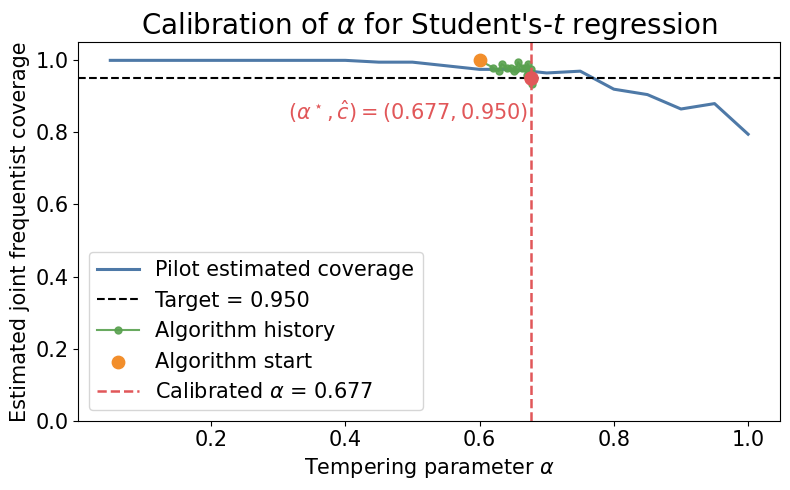

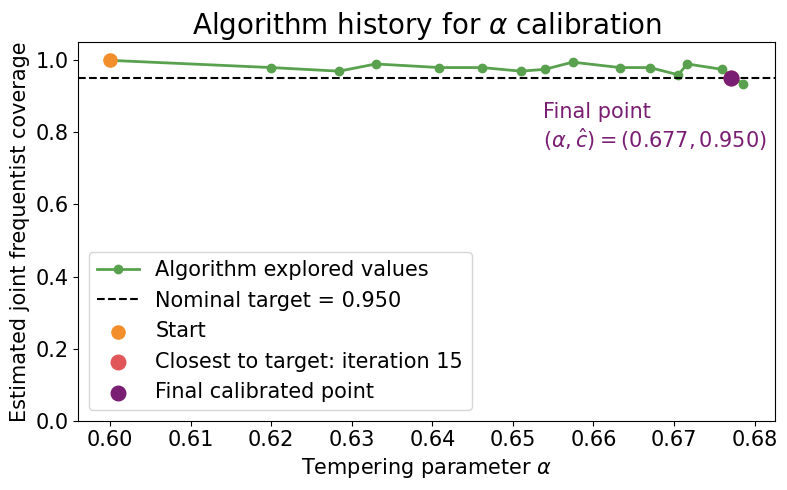

In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# OUTPUT DIRECTORY
# ============================================================
output_dir = "results_sensitivity_calibration_alpha"
os.makedirs(output_dir, exist_ok=True)


# ============================================================
# PILOT-GRID RESULTS RECORDED IN THE NOTEBOOK
# ============================================================
alpha_grid = np.linspace(0.05, 1.0, 20)

coverage_grid = np.array([
    1.000,
    1.000,
    1.000,
    1.000,
    1.000,
    1.000,
    1.000,
    1.000,
    0.995,
    0.995,
    0.985,
    0.975,
    0.975,
    0.965,
    0.970,
    0.920,
    0.905,
    0.865,
    0.880,
    0.795
])


# ============================================================
# RECONSTRUCT STOCHASTIC-APPROXIMATION HISTORY
# ============================================================
coverage_history = np.array([
    1.000,
    0.980,
    0.970,
    0.990,
    0.980,
    0.980,
    0.970,
    0.975,
    0.995,
    0.980,
    0.980,
    0.960,
    0.990,
    0.975,
    0.935,
    0.950
])

target_cov = 0.95
step_scale = 0.4
step_exponent = 0.51
alpha_current = 0.6

history = []

for iteration, coverage in enumerate(coverage_history):
    step = step_scale * (iteration + 1) ** (-step_exponent)
    error = coverage - target_cov

    history.append({
        "iter": iteration,
        "alpha": alpha_current,
        "coverage_hat": coverage,
        "target_cov": target_cov,
        "error": error,
        "step": step
    })

    # Update alpha unless this is the final recorded iteration
    if iteration < len(coverage_history) - 1:
        alpha_current = alpha_current + step * error
        alpha_current = np.clip(alpha_current, 0.05, 1.0)

alpha_calibrated = history[-1]["alpha"]
coverage_at_alpha = history[-1]["coverage_hat"]

print(f"Calibrated alpha: {alpha_calibrated:.15f}")
print(f"Estimated coverage: {coverage_at_alpha:.3f}")


# ============================================================
# COMBINED PILOT CURVE, HISTORY, AND CALIBRATED ALPHA
# ============================================================
def plot_calibrated_alpha(
    alpha_grid,
    coverage_grid,
    alpha_calibrated,
    target_cov=0.95,
    coverage_at_alpha=None,
    history=None,
    save_path=None
):
    alpha_grid = np.asarray(alpha_grid)
    coverage_grid = np.asarray(coverage_grid)

    if coverage_at_alpha is None:
        calibrated_coverage = np.interp(
            alpha_calibrated,
            alpha_grid,
            coverage_grid
        )
    else:
        calibrated_coverage = coverage_at_alpha

    fig, ax = plt.subplots(figsize=(8, 5))

    # Pilot coverage curve
    ax.plot(
        alpha_grid,
        coverage_grid,
        linewidth=2.2,
        color="#4E79A7",
        label="Pilot estimated coverage"
    )

    # Nominal target
    ax.axhline(
        target_cov,
        linestyle="--",
        linewidth=1.5,
        color="black",
        label=rf"Target = {target_cov:.3f}"
    )

    # Stochastic-approximation history
    if history:
        alpha_history = np.array([
            row["alpha"] for row in history
        ])

        coverage_history = np.array([
            row["coverage_hat"] for row in history
        ])

        ax.plot(
            alpha_history,
            coverage_history,
            linestyle="-",
            linewidth=1.5,
            marker="o",
            markersize=5,
            color="#59A14F",
            alpha=0.9,
            label="Algorithm history"
        )

        ax.scatter(
            alpha_history[0],
            coverage_history[0],
            s=80,
            color="#F28E2B",
            zorder=6,
            label="Algorithm start"
        )

    # Final calibrated alpha
    ax.axvline(
        alpha_calibrated,
        linestyle="--",
        linewidth=1.8,
        color="#E15759",
        label=rf"Calibrated $\alpha$ = {alpha_calibrated:.3f}"
    )

    ax.scatter(
        alpha_calibrated,
        calibrated_coverage,
        s=90,
        color="#E15759",
        zorder=7
    )

    ax.annotate(
        rf"$(\alpha^\star,\hat{{c}})"
        rf"=({alpha_calibrated:.3f},{calibrated_coverage:.3f})$",
        xy=(alpha_calibrated, calibrated_coverage),
        xytext=(-175, -30),
        textcoords="offset points",
        fontsize=15,
        color="#E15759"
    )

    ax.set_xlabel(
        r"Tempering parameter $\alpha$",
        fontsize=15
    )

    ax.set_ylabel(
        "Estimated joint frequentist coverage",
        fontsize=15
    )

    ax.set_title(
        r"Calibration of $\alpha$ for Student's-$t$ regression",
        fontsize=20
    )

    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="both", labelsize=15)
    ax.legend(fontsize=15)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)


# ============================================================
# ALGORITHM-HISTORY PLOT
# ============================================================
def plot_algorithm_history(
    history,
    target_cov=0.95,
    save_path=None
):
    if history is None or len(history) == 0:
        raise ValueError("History is empty.")

    alpha_history = np.array([
        row["alpha"] for row in history
    ])

    coverage_history = np.array([
        row["coverage_hat"] for row in history
    ])

    iteration_history = np.array([
        row["iter"] for row in history
    ])

    # Point closest to nominal coverage
    best_index = np.argmin(
        np.abs(coverage_history - target_cov)
    )

    alpha_best = alpha_history[best_index]
    coverage_best = coverage_history[best_index]
    iteration_best = iteration_history[best_index]

    alpha_final = alpha_history[-1]
    coverage_final = coverage_history[-1]

    fig, ax = plt.subplots(figsize=(8, 5))

    # Explored path
    ax.plot(
        alpha_history,
        coverage_history,
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=6,
        color="#59A14F",
        label="Algorithm explored values"
    )

    # Nominal target
    ax.axhline(
        target_cov,
        linestyle="--",
        linewidth=1.5,
        color="black",
        label=rf"Nominal target = {target_cov:.3f}"
    )

    # Starting point
    ax.scatter(
        alpha_history[0],
        coverage_history[0],
        s=90,
        color="#F28E2B",
        zorder=6,
        label="Start"
    )

    # Point closest to target
    ax.scatter(
        alpha_best,
        coverage_best,
        s=110,
        color="#E15759",
        zorder=7,
        label=f"Closest to target: iteration {iteration_best}"
    )

    # Final calibrated point
    ax.scatter(
        alpha_final,
        coverage_final,
        s=110,
        color="#7A1E74",
        zorder=8,
        label="Final calibrated point"
    )

    ax.annotate(
        "Final point\n"
        + rf"$(\alpha,\hat{{c}})"
        + rf"=({alpha_final:.3f},{coverage_final:.3f})$",
        xy=(alpha_final, coverage_final),
        xytext=(-135, -50),
        textcoords="offset points",
        fontsize=15,
        color="#7A1E74"
    )

    ax.set_xlabel(
        r"Tempering parameter $\alpha$",
        fontsize=15
    )

    ax.set_ylabel(
        "Estimated joint frequentist coverage",
        fontsize=15
    )

    ax.set_title(
        r"Algorithm history for $\alpha$ calibration",
        fontsize=20
    )

    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="both", labelsize=15)
    ax.legend(fontsize=15)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)


# ============================================================
# GENERATE SUPPLEMENTARY FIGURE 17
# ============================================================
plot_calibrated_alpha(
    alpha_grid=alpha_grid,
    coverage_grid=coverage_grid,
    alpha_calibrated=alpha_calibrated,
    target_cov=target_cov,
    coverage_at_alpha=coverage_at_alpha,
    history=history,
    save_path=os.path.join(
        output_dir,
        "calibrated_alpha_with_history.pdf"
    )
)

plot_algorithm_history(
    history=history,
    target_cov=target_cov,
    save_path=os.path.join(
        output_dir,
        "algorithm_history.pdf"
    )
)